Q1. Missing Data Identification

Scenario: 
 The hospital suspects incomplete patient records.

Task:

Identify missing values in each column

Calculate percentage of missing data

In [9]:
import pandas as pd
df = pd.read_csv('Healthcare_Data_Cleaning_Dataset.csv')

In [10]:
# Missing values count
missing_values = df.isnull().sum()


In [11]:
# Missing values percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

In [12]:
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage Missing (%)': missing_percentage.round(2)
})

print(missing_summary)

                    Missing Values  Percentage Missing (%)
Patient_ID                       0                    0.00
Age                            600                   11.76
Gender                           0                    0.00
City                             0                    0.00
Diagnosis                        0                    0.00
Hospital_Visits                  0                    0.00
Treatment_Cost                 593                   11.63
Insurance_Coverage               0                    0.00
Admission_Date                   0                    0.00


In [ ]:
Q2. Handling Missing Age

Scenario: 
 Age is critical for medical analysis, but some values are missing.

Task:

Replace missing Age values with an appropriate method

Justify your choice (mean/median)

In [ ]:
# check missing values in Age 

In [7]:
import pandas as pd
# Load dataset
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")


In [8]:
print("Missing Age values before:", df ['Age'].isnull().sum())

Missing Age values before: 600


In [13]:
# Replace missing Age values with median
median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace=True)


C:\Users\pc\AppData\Local\Temp\ipykernel_20468\3179907581.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(median_age, inplace=True)


In [14]:
#verify
print("Missing Age values after:",df['Age'].isnull().sum())
print("Missing age used :", median_age)

Missing Age values after: 0
Missing age used : 50.0


#Q.3. Handling Missing Treatment Cost

Scenario: 
 Treatment cost is highly skewed due to expensive treatments.

Task:

Handle missing Treatment_Cost values

Choose the correct imputation method and explain why

In [16]:
import pandas as pd

# Load dataset
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

In [20]:
# check the missing values before imputations

print("Missing Treatment_Cost values before:",
     df['Treatment_Cost'].isnull().sum())

Missing Treatment_Cost values before: 593


In [24]:
# calculate median 
median_cost= df['Treatment_Cost'].median()

# Replace missing vaues with median 
df['Treatment_Cost'].fillna(median_cost, inplace= True)

C:\Users\pc\AppData\Local\Temp\ipykernel_20468\1981503906.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Treatment_Cost'].fillna(median_cost, inplace= True)


In [25]:
#verify 
print("Missing Treatment_Cost values after:",

df['Treatment_Cost'].isnull().sum())

Missing Treatment_Cost values after: 0


In [26]:
print("Median Treatment Cost used :",median_cost)

Median Treatment Cost used : 24797.0


#Q4.Duplicate Patient Records

Scenario: 
 Some patient records were entered multiple times.

Task:

Identify duplicate rows

Remove duplicates

Compare dataset size before and after

In [27]:
import pandas as pd

# Load dataset
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

In [29]:
# count dupicate rows 
duplicate_count  = df.duplicated().sum()

print("Numbers of duplicated rows:", duplicate_count)

Numbers of duplicated rows: 99


In [37]:
# Dataset size before removing Duplicates 
before_rows = len(df)

# remove Duplicates 
df_clean = df.drop_duplicates()

# Dataset size after removing Duplicates 
after_rows = len(df)

# data set size after removing duplicates 
print("Rows before removing duplicates :", before_rows)
print("Rows after removing duplicates :", after_rows)
print("Duplicates removed :", before_rows - after_rows)

Rows before removing duplicates : 5100
Rows after removing duplicates : 5100
Duplicates removed : 0


In [55]:
# compared dataset size before and after
comparison = pd.DataFrame({
    "Metric":["Rows Before","Rows After","Duplicates Removed"],
    "Value": [before_rows, after_rows, before_rows - after_rows]

})
print(comparison)

               Metric  Value
0         Rows Before   5100
1          Rows After   5100
2  Duplicates Removed      0


#Q5. Invalid Age Values (Data Quality Check)

Scenario: 
 Some patients have unrealistic age values (e.g., >100 or <0).

Task:

Detect such records

Decide whether to remove or correct them

In [56]:
import pandas as pd

#load dataset 
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

In [59]:
# find invalid   age records
invalid_age = df[(df['Age']<0)  | (df['Age']>100)]

print("Number of invalid age records:",len(invalid_age))
print(invalid_age)

Number of invalid age records: 0
Empty DataFrame
Columns: [Patient_ID, Age, Gender, City, Diagnosis, Hospital_Visits, Treatment_Cost, Insurance_Coverage, Admission_Date]
Index: []


In [64]:
# remove invalid age records 
df_clean = df[(df['Age']>= 0) & (df['Age']<= 100)]

print("Rows before cleaning :",len(df))
print("Rows after cleaning :",len(df_clean))

Rows before cleaning : 5100
Rows after cleaning : 4500


Q6. Outlier Detection (Treatment Cost)

Scenario: 
 Extreme treatment costs are affecting analysis.

Task:

Detect outliers using IQR method

Display number of outliers

In [84]:
import pandas as pd

# Load dataset
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

# Calculate Q1 and Q3
Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[
    (df['Treatment_Cost'] < lower_bound) |
    (df['Treatment_Cost'] > upper_bound)
]

# Display results
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("\nNumber of Outliers:", len(outliers))
print(outliers)

Q1: 12498.0
Q3: 37922.0
IQR: 25424.0
Lower Bound: -25638.0
Upper Bound: 76058.0

Number of Outliers: 50
      Patient_ID   Age  Gender       City     Diagnosis  Hospital_Visits  \
53         13152  91.0  Female    Chennai      COVID-19               13   
86         10064  28.0  Female  Hyderabad  Hypertension               16   
124        17035  59.0    Male      Delhi           Flu                9   
183        15855  36.0    Male     Mumbai      Diabetes                1   
215        19561  29.0    Male     Mumbai           Flu               16   
332        11686  51.0    Male      Delhi        Asthma               16   
382        10876  58.0  Female  Bangalore  Hypertension                1   
416        14070   NaN    Male  Hyderabad           Flu                6   
452        10851  42.0  Female  Bangalore      COVID-19               15   
796        18150  37.0  Female  Bangalore           Flu               17   
833        19361  41.0  Female      Delhi      Diabetes     

Q7. Outlier Treatment

Scenario: 
The business team wants to retain all records.

Task:

Apply capping (Winsorization) on Treatment_Cost

Use 5th and 95th percentile

In [90]:
import pandas as pd 
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

# calculate 5th and 95th Percentile 

lower_cap= df['Treatment_Cost'].quantile(0.05)
upper_cap= df['Treatment_Cost'].quantile(0.95)

print("5th Precentile:",lower_cap)
print("95th Precentile:",upper_cap)

# Apply winsorization(capping)
df['Treatment_Cost_Capped']= df['Treatment_Cost'].clip(
    lower= lower_cap,
    upper=upper_cap
)

#Compare before and after
print("\nOriginal Summary:")
print(df['Treatment_Cost'].describe())

print("\nCapped Summary:")
print(df['Treatment_Cost_Capped'].describe())

5th Precentile: 2914.6
95th Precentile: 48188.1

Original Summary:
count      4507.000000
mean      26920.151157
std       23224.930985
min         526.000000
25%       12498.000000
50%       24797.000000
75%       37922.000000
max      199702.965333
Name: Treatment_Cost, dtype: float64

Capped Summary:
count     4507.000000
mean     25260.722032
std      14351.799874
min       2914.600000
25%      12498.000000
50%      24797.000000
75%      37922.000000
max      48188.100000
Name: Treatment_Cost_Capped, dtype: float64


In [ ]:
Q8. Transformation

Scenario: 
 Treatment cost is highly skewed.

Task:

Apply log transformation

Create a new column

Compare before vs after distribution

In [93]:
import pandas as pd 
import numpy as np
# load dataset 
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")

In [97]:
# create a new column with log transformation 
df['Log_Treatment_Cost']=np.log1p(df['Treatment_Cost'])

# Display first few rows 
print(df[['Treatment_Cost','Log_Treatment_Cost']].head())

   Treatment_Cost  Log_Treatment_Cost
0         41010.0           10.621596
1         12194.0            9.408781
2         45086.0           10.716349
3         40842.0           10.617491
4          9873.0            9.197660


In [101]:
#Compare Before vs After Distribution
print("Original Treatment Cost")
print(df['Treatment_Cost'].describe())

print("\nLog Transformed Treatment Cost")
print(df['Log_Treatment_Cost'].describe())

Original Treatment Cost
count      4507.000000
mean      26920.151157
std       23224.930985
min         526.000000
25%       12498.000000
50%       24797.000000
75%       37922.000000
max      199702.965333
Name: Treatment_Cost, dtype: float64

Log Transformed Treatment Cost
count    4507.000000
mean        9.878058
std         0.914197
min         6.267201
25%         9.433404
50%        10.118518
75%        10.543313
max        12.204591
Name: Log_Treatment_Cost, dtype: float64


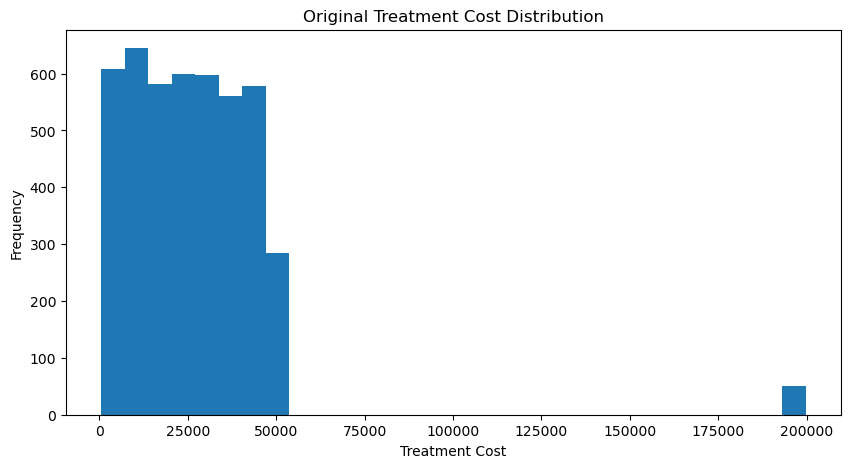

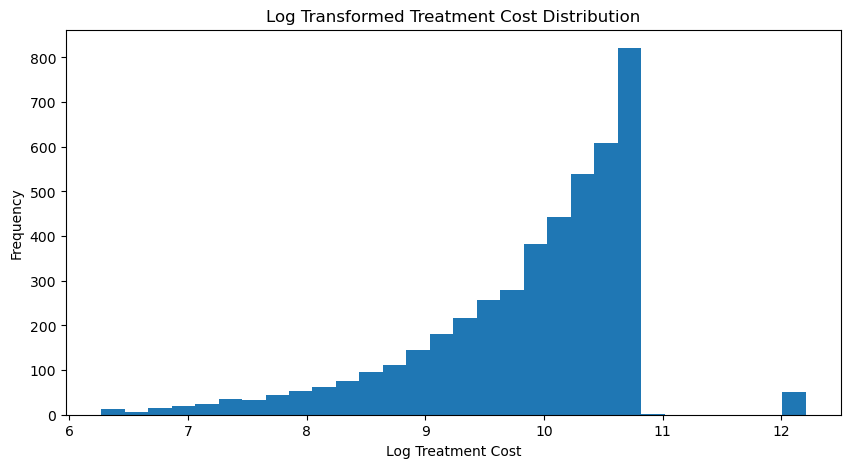

In [102]:
import matplotlib.pyplot as plt

# Original distribution
plt.figure(figsize=(10,5))
plt.hist(df['Treatment_Cost'].dropna(), bins=30)
plt.title('Original Treatment Cost Distribution')
plt.xlabel('Treatment Cost')
plt.ylabel('Frequency')
plt.show()

# Log-transformed distribution
plt.figure(figsize=(10,5))
plt.hist(df['Log_Treatment_Cost'].dropna(), bins=30)
plt.title('Log Transformed Treatment Cost Distribution')
plt.xlabel('Log Treatment Cost')
plt.ylabel('Frequency')
plt.show()

Q9. Time-Based Missing Handling

Scenario: 
 Admission dates should follow a logical sequence.

Task:

Sort data by Admission_Date

Apply forward fill or backward fill where appropriate

Justify your choice

In [103]:
import pandas as pd

df = pd.read_csv("healthcare_data_cleaning_dataset.csv")


In [112]:
df['Admission_Date']=pd.to_datetime(df['Admission_Date'])
# sort the dataset
df =df.sort_values(by='Admission_Date')

# Apply forward fill and Backward fill
df=df.ffill()
df=df.bfill()

# check remaining missing values 
print(df.isnull().sum())

Patient_ID            0
Age                   0
Gender                0
City                  0
Diagnosis             0
Hospital_Visits       0
Treatment_Cost        0
Insurance_Coverage    0
Admission_Date        0
dtype: int64
